# 1. Introduction

My notebook will cover everything regarding the training, evaluation, bias analysis, and interpretability of ML models for the diagnosis of ADHD using demographic, psychometric, and fMRI brain connectivity data. 

**Objectives:**
- I want to train different classifiers on the processed data.
- I will evaluate each model using suitable performance metrics.
- Make sure the prediction is not biased against women.
- I will examine model predictions using SHAP or LIME for interpretability.

**Models considered:**
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier
- LightGBM Classifier

The final objective is to compare predictive performance, interpretability, and subgroup behavior in this research dataset.


# 2. Load Final Data

I load the final processed datasets that were created at the end stage of data exploration and processing.

- My **train_final_with_labels.csv** contains 849 participants.
- My **test_final_with_labels.csv** contains 364 participants.
- Both datasets include these features:
- Metadata A (numeric)
- Metadata B (categorical)
- Brain connectome (after KernelPCA)
- Labels: ADHD_Outcome (target) and Sex_F (for bias analysis)

In [1]:
# Libraries
import pandas as pd

# I Load my final datasets
train_df = pd.read_csv('final_datasets/train_final_with_labels.csv')
test_df = pd.read_csv('final_datasets/test_final_with_labels.csv')

# Show the preview of the shape
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Here is the preview of the first few rows
train_df.head()

Train shape: (849, 41)
Test shape: (364, 41)


,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Externalizing,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Internalizing,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Peer_Problems,...,connectome_kpca_13,connectome_kpca_14,connectome_kpca_15,connectome_kpca_16,connectome_kpca_17,connectome_kpca_18,connectome_kpca_19,connectome_kpca_20,Sex_F,ADHD_Outcome
0,8.0,11.0,16.0,3.0,6.0,5.0,15.0,41.0,3.0,2.0,...,-0.036645,-0.077572,-0.029061,0.082418,-0.079027,-0.060398,0.031010,-0.000213,0,1
1,9.0,11.0,23.0,2.0,8.0,12.0,20.0,48.0,6.0,6.0,...,0.015004,-0.017487,-0.039956,-0.029318,-0.013446,0.028521,-0.001016,-0.073370,0,1
2,8.0,10.0,16.0,2.0,4.0,6.0,9.0,44.0,3.0,3.0,...,0.000668,0.002596,0.000731,0.000692,-0.002245,-0.001359,-0.000403,0.003598,0,1
3,8.0,13.0,21.0,5.0,8.0,8.0,9.0,46.0,4.0,4.0,...,0.000116,0.007986,0.012450,-0.012519,-0.002961,-0.004843,-0.003346,-0.000159,0,1
4,5.0,6.0,8.0,1.0,2.0,2.0,12.0,36.0,2.0,0.0,...,0.032137,-0.004413,-0.001354,-0.006852,0.016958,0.064498,-0.096403,-0.071857,0,1


# Analysis of Load Final Data

- Train consisted of 849 samples and 41 features.
- Testing consisted of 364 samples and 41 features.
- Both of my shapes are correct and consistent with earlier splits.

## Feature Composition:
- Actions and behavior include some examples like SDQ_SDQ_Hyperactivity and lSDQ_SDQ_Externalizing.
- The brain connectome features the use of 20 components which include connectome-kpca-1 to connectome-kpca-20 according to my notebook 1.

## Target Variables:
- Males write with the number 0 and females describe with the number 1.
- The number 0 means people do not have ADHD but the number 1 means they have ADHD.

## Features:
- There are no missing values.
- Every feature is a number that is scaled.
- The kernel PCA features should have zero mean.


# 3. Prepare Features and Labels

I prepare my dataset for modeling. I will separate features from the target variable, check for class balance, and ensure the structure is ready for training.

**My tasks are:**
- I separate Features and Targets into **features_train**, **features_test**, **labels_train**, and **labels_test**.
- All variables except the target **ADHD_Outcome** and **participant_id** are saved in **features_train** and **features_test**.
- **ADHD_Outcome** is the target variable that I am trying to predict it.

**Check Target Distribution:**
- To see if both classes have enough data, I analyze the data to detect class imbalance within the train and test set.
- This will help me to decide the use of **class_weight=balanced** or resampling.

**My note are:**
- My features already include:
- Choose the behavioral and parental score of SDQ & APQ.
- I will take demographic data from Metadata B.
- I transformed twenty Brain Connectome features by KernelPCA.
- The feature **Sex_F** is also retained for bias analysis.

**This step is important because:**
- This split of data will ensure a clean structure that can be reused to feed into various ML models.
- Class imbalance check is an essential step for me to avoid getting biased predictions as **female ADHD cases are underdiagnosed**.

In [3]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

def prepare_features_and_labels(train_df, test_df, target_col='ADHD_Outcome', id_col='participant_id'):
    # I separate features and labels
    features_train = train_df.drop(columns=[target_col, id_col])
    labels_train = train_df[target_col]

    features_test = test_df.drop(columns=[target_col, id_col])
    labels_test = test_df[target_col]

    # I separate Sex_F before scaling
    sex_f_train = features_train['Sex_F']
    sex_f_test = features_test['Sex_F']

    # Here I drop Sex_F from features to be scaled
    features_train_scaled = features_train.drop(columns=['Sex_F'])
    features_test_scaled = features_test.drop(columns=['Sex_F'])

    # This part of my code is about scale numerical features
    scaler = StandardScaler()
    features_train_scaled = pd.DataFrame(scaler.fit_transform(features_train_scaled), columns=features_train_scaled.columns)
    features_test_scaled = pd.DataFrame(scaler.transform(features_test_scaled), columns=features_test_scaled.columns)

    # Add Sex_F back without scaling
    features_train = pd.concat([features_train_scaled, sex_f_train.reset_index(drop=True)], axis=1)
    features_test = pd.concat([features_test_scaled, sex_f_test.reset_index(drop=True)], axis=1)

    # This part is about show clear info
    print(f"\nTraining set has {features_train.shape[0]} participants and {features_train.shape[1]} features.")
    print(f" Test set has {features_test.shape[0]} participants and {features_test.shape[1]} features.")

    # Class distribution
    print("\nTraining target distribution:")
    print(labels_train.value_counts(normalize=True))

    print("\nTesting target distribution:")
    print(labels_test.value_counts(normalize=True))

    print("\nFeature preparation and scaling completed successfully (with Sex_F untouched).")
    return features_train, features_test, labels_train, labels_test

# Call my fuction to see my shape of data
features_train, features_test, labels_train, labels_test = prepare_features_and_labels(train_df, test_df)


Training set has 849 participants and 39 features.
 Test set has 364 participants and 39 features.

Training target distribution:
ADHD_Outcome
1    0.685512
0    0.314488
Name: proportion, dtype: float64

Testing target distribution:
ADHD_Outcome
1    0.684066
0    0.315934
Name: proportion, dtype: float64

Feature preparation and scaling completed successfully (with Sex_F untouched).


# Analysis of Prepare Features and Labels

**Data Shapes:**
- Train Features: The number 849 is about the training sample and 39 is about features except for the target.
- Train Labels: The number 849 is about target labels for training.
- Test Features: The number 364 is about testing samples and 39 is about features.
- Test Labels: The number 364 is about target labels for test.

**Feature Scaling (Standardization):**
- In this part, I use StandardScaler to standardize the feature values.
- I use these features to create the mean and variance to 0.
- Here scaling is fixed on training set (fit_transform) to prevent data leakage.
- The same transformation is applied to the test set, using the parameters learned from training data.

This part is necessary for my models like Logistic Regression which are sensitive to feature scales (Standardization).

**Target Distribution:**
- Training set (labels_train): ADHD = 1 equal 68.55% and ADHD = 0 equal 31.44%
- Test set (labels_test): ADHD = 1 equal 68.40% and ADHD = 0 equal 31.59%

**Interpretation:**
- Most of the participants in the dataset are diagnosed as having ADHD.
- The training and testing sets almost represent the same class distributions indicating the correct application of stratified splitting which is exactly what I want.

**Summary of my output:**
- The columns for features and targets are separated.
- The shapes of the training and testing sets are correct.
- The train and test sets have the same ratio of the target classes.


# 4. Modeling Strategy Overview

My general training, testing, and interpreting plan for ML models will be used for the prediction’s ADHD.

## Here is my Modeling Plan

**Models to Train:**
- I will use **Logistic Regression** to facilitate interpretability and baseline comparison.
- I want to use **Random Forest** due to its ensemble power.
- I use **XGBoost** due to its high performance and ability to overcome class imbalance.
- In the end, I want to use **LightGBM** for training and power similar to XGBoost.

**Evaluation Metrics:**
- Accuracy
- F1-Score
- ROC-AUC
- Confusion Matrix

**Validation Strategy:**
- Stratified K-Fold Cross Validation will keep the ratio of the class for ADHD.
- I use **class_weight=balanced** or **scale_pos_weight** to solve imbalance.

**Bias Check:**
- I want to use the Sex_F feature to compare model performance separately for males and females.
- With **F1-score** I can check the evaluation accuracy for each gender group.

**Interpretability:**
- Use SHAP:
- Global feature importance.
- I can describe the following inputs and outputs
- I can check the coefficients for Logistic Regression as well.

# 5. Model Evaluation Function analyze_model_performance

This function that I want to create is for training and testing a model on the dataset. It also provides a visual and a metric. It helps me to standardize evaluation across multiple models.

**Function responsibilities:**
- Make the model learn by using **model.fit(...)**.
- I want to make estimations and likelihood ratings on the trial collection.
  
**My compute key metrics are:**  
- **Accuracy**  
- **F1-score**  
- **ROC AUC**

**My optional visualizations:**
- I will use **Confusion Matrix** with customizable color using **confusion_cmap**.
- My plan is to create **ROC Curve** with customizable using **roc_curve_color**.
  
**Feature importance or coefficients:**  
- Top N most important features from tree models. 
- A chart or graph assigned to a Linear models.
  
**SHAP Summary Plots**  
- Bar plot (**plot_type="bar"**)  
- Full distribution plot

**Parameters:**
- Model shows the machine learning model for training.
- I use model_name for headings and label sections.
- There are two parts for training and evaluation and they are features_train and features_test.
- For related aims, I use labels_train and labels_test.
- I will use feature_names for a list of column names.
- Optional styling controls are these parts confusion_cmap, roc_curve_color, shap_color, and top_n_features.
- For changing each plot type I use plot_confusion_matrix and plot_roc_curve.

**Returns:**
- Trained model  
- Predictions on test set  
- Predicted probabilities on test set

This function that I will create causes increased consistency, decreases that some code repeated, and simplifies the model. comparison.

In [5]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

def analyze_model_performance(
    model, model_name,
    features_train, labels_train,
    features_test, labels_test,
    feature_names,
    confusion_cmap="Blues",              
    roc_curve_color="blue",              
    shap_color="lightgreen",             
    top_n_features=15,                    
    plot_confusion_matrix=True,
    plot_roc_curve=True,
    plot_feature_importance=True,
    plot_shap_bar=True,           
    plot_shap_summary=True
):
    # This section is about Train the model
    model.fit(features_train, labels_train)

    # In this part of my code I want to  predict the ADHD labels and their probabilities for the test data
    y_pred = model.predict(features_test)
    y_proba = model.predict_proba(features_test)[:, 1]

    # I want to measure the model’s performance using accuracy, F1, and ROC AUC
    acc = accuracy_score(labels_test, y_pred)
    f1 = f1_score(labels_test, y_pred)
    roc_auc = roc_auc_score(labels_test, y_proba)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    # The first chart is Confusion Matrix
    if plot_confusion_matrix:
        cm = confusion_matrix(labels_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ADHD", "ADHD"])
        disp.plot(cmap=confusion_cmap)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.grid(False)
        plt.tight_layout()
        plt.show()

     # The second chart is ROC curve plot   
    if plot_roc_curve:
        fpr, tpr, _ = roc_curve(labels_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color=roc_curve_color)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        
    # The third chart is Feature Importance or Coefficients
    if plot_feature_importance:
        # Tree-based models
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:top_n_features]
            plt.figure(figsize=(8, 5))
            plt.bar(range(len(indices)), importances[indices], color=shap_color, edgecolor='black')
            plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
            plt.title(f"Top Feature Importances - {model_name}")
            plt.tight_layout()
            plt.show()

    # The fourth chart is Top Coefficients
        elif hasattr(model, "coef_"):
            coef = model.coef_[0]
            coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
            coef_df['abs_coef'] = coef_df['Coefficient'].abs()
            coef_df = coef_df.sort_values(by='abs_coef', ascending=False).head(top_n_features)
            plt.figure(figsize=(8, 5))
            colors = ['seagreen' if c > 0 else 'indianred' for c in coef_df['Coefficient']]
            plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors)
            plt.xticks(rotation=90)
            plt.title(f"Top Coefficients - {model_name}")
            plt.tight_layout()
            plt.show()

        
    # SHAP
    try:
        if 'XGB' in model_name or 'LightGBM' in model_name or 'Random Forest' in model_name:
            explainer = shap.TreeExplainer(model)
        else:
            explainer = shap.Explainer(model, features_train)

        shap_values = explainer.shap_values(features_test)

        # The fifth chart is SHAP Bar Plot
        if plot_shap_bar:
            if isinstance(shap_values, list):
                shap.summary_plot(shap_values[1], features_test, plot_type="bar", color=shap_color, show=False)
            else:
                shap.summary_plot(shap_values, features_test, plot_type="bar", color=shap_color, show=False)
            plt.title(f"SHAP Summary Plot (Bar) - {model_name}")
            plt.show()

        # The sixth chart is SHAP Full Summary Plot
        if plot_shap_summary:
            if isinstance(shap_values, list):
                shap.summary_plot(shap_values[1], features_test, show=False)
            else:
                shap.summary_plot(shap_values, features_test, show=False)
            plt.title(f"SHAP Summary Plot - {model_name}")
            plt.tight_layout()
            plt.show()
    
    except Exception as e:
        if plot_shap_bar or plot_shap_summary:
            print(f"SHAP skipped for {model_name}. Reason: {str(e)}")

    
    return model, y_pred, y_proba

# 6. Fairness Evaluation Function analyze_fairness_by_sex

This function examines the **fairness of a trained model** by comparing its performance between two groups using this feature **Sex_F** and if I want to introduce the number, number 1 is females and number 0 is males.

**My purpose is:**  
I check whether the model has different performance for male and female participants which can be a gender bias, especially for conditions like ADHD that are underdiagnosed in females.

**Function Highlights:**
- Automatically identify the **Sex_F** feature and separate test samples into 2 parts:
- Number one is female group and I introduce with **Sex_F = 1**.  
- Number two is male group and I introduce with **Sex_F = 0**.
  
**Evaluate each group separately according to:**
- Accuracy
- F1-score
- ROC AUC
- Print results next to each other for comparison

**Requirements:**
- Sex_F should be show in feature_names.
- Model should support two methods **.predict()** and **.predict_proba()**.

**Usage Scenario:**  
Use this function **after model evaluation** to compare recorded performance across the two sex groups. This exploratory analysis does not certify model fairness.

In [7]:
def analyze_fairness_by_sex(model, features_test, labels_test, feature_names):
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

    # I check that 'Sex_F' be in features
    if 'Sex_F' not in feature_names:
        print("Error: 'Sex_F' feature not found in the dataset.")
        return
    
    # Find the index of 'Sex_F' in the feature list
    sex_f_index = list(feature_names).index('Sex_F')
    is_female = features_test.iloc[:, sex_f_index] == 1
    is_male = features_test.iloc[:, sex_f_index] == 0
    # I define groups for analysis (females and males)
    groups = {
        "Female (Sex_F=1)": is_female,
        "Male (Sex_F=0)": is_male
    }

    print("\n=== Fairness Analysis by Sex ===")
    # I create a loop over both groups to evaluate the model's performance separately
    for group_name, mask in groups.items():
        X_group = features_test[mask]
        y_true = labels_test[mask]
        y_pred = model.predict(X_group)
        y_proba = model.predict_proba(X_group)[:, 1]

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_proba)

        print(f"\nGroup: {group_name}")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  F1-score: {f1:.4f}")
        print(f"  ROC AUC: {roc_auc:.4f}")

# 7. Model Selection with Cross-Validation and Hyperparameter Tuning
This function automates model training and tuning through Stratified K-Fold cross-validation and hyperparameter tuning. It assists many classifiers. Also, to get a good and fair evaluation, I would use F1-score.

In [9]:
import os
import contextlib
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def run_cv_and_tune(model_name, features_train, labels_train, n_iter=10, random_state=42):

    
   
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    scorer = make_scorer(f1_score)
    # If my model is Logistic Regression, define model and parameter grid for tuning
    if model_name == "Logistic":
        model = LogisticRegression(class_weight='balanced', max_iter=50000, random_state=random_state)
        param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
        search = GridSearchCV(model, param_grid, cv=cv, scoring=scorer, n_jobs=-1)
    # If my model is Random Forest, define model and hyperparameter grid
    elif model_name == "Random Forest":
        model = RandomForestClassifier(class_weight='balanced', random_state=random_state)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=cv, scoring=scorer, random_state=random_state, n_jobs=-1)
    # If my model is XGBoost, define model and its parameter grid
    elif model_name == "XGBoost":
        model = XGBClassifier(eval_metric='logloss', random_state=random_state)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'scale_pos_weight': [0.5, 1, 2]
        }
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=cv, scoring=scorer, random_state=random_state, n_jobs=-1)
    # If my model is LightGBM, define model and its parameter grid
    elif model_name == "LightGBM":
        model = LGBMClassifier(random_state=random_state, verbosity=-1,silent=True )
        param_grid = {
            'num_leaves': [80, 100, 120],
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.04, 0.05, 0.06, 0.07],
            'scale_pos_weight': [0.5, 1, 2],
            'min_data_in_leaf': [10, 20,30], 
            'min_gain_to_split': [0.0, 0.05, 0.1],
            'reg_alpha': [0, 0.1, 0.3, 0.5],  # I set these 2 grid to avoid overfitting
            'reg_lambda': [0, 0.1, 0.3, 0.5]
        }
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=cv, scoring=scorer, random_state=random_state, n_jobs=-1)

    else:
        raise ValueError("Unsupported model name. Choose from: 'Logistic', 'Random Forest', 'XGBoost', 'LightGBM'")

    with contextlib.redirect_stdout(open(os.devnull, 'w')), contextlib.redirect_stderr(open(os.devnull, 'w')):
        search.fit(features_train, labels_train)
    best_model = search.best_estimator_
    best_params = search.best_params_
    best_score = search.best_score_

    print(f"\n=== Best Parameters for {model_name} ===")
    print(best_params)
    print(f"Mean F1 Score: {best_score:.4f}")

    return best_model, best_params, best_score


# 8.1 Model Training with Cross-Validation and Hyperparameter Tuning
This part of my work applies the run_cv_and_tune function to carry out a randomized search with cross-validation and identify the best hyperparameters for the model chosen. My final model that was trained will evaluate the test data.

In [11]:
best_model_lg, best_params, best_score = run_cv_and_tune("Logistic", features_train, labels_train)


=== Best Parameters for Logistic ===
{'C': 0.01}
Mean F1 Score: 0.8088


# Analysis of output

- The best hyperparameter in this part I found is **C = 0.01** which has more regularization.
- This output says that a simple model performed better (less overfitting) on the data.
- The mean F1 score of **0.8088** that is achieved in a 5-fold cross-validation on the training data indicates the precision-recall trade-off is good.

This result shows that Logistic Regression, even as a simple model, performs well and is a good baseline for ADHD prediction.

# 8.2 Train and Evaluate Model: Logistic Regression

I will evaluate the Logistic Regression model with the best hyperparameters.

**The analyze_model_performance() function:**
- I use the final model on the test set.
- Here I should calculate Accuracy, F1-score, and ROC AUC.
- Shows the Confusion Matrix and ROC Curve.
- I will display the **Top Feature Coefficients** to help explain the model's output.

I skip SHAP plots here as Logistic Regression provides interpretable coefficients directly.


=== Logistic Regression (Final) ===
Accuracy: 0.8049
F1-score: 0.8493
ROC AUC: 0.8853


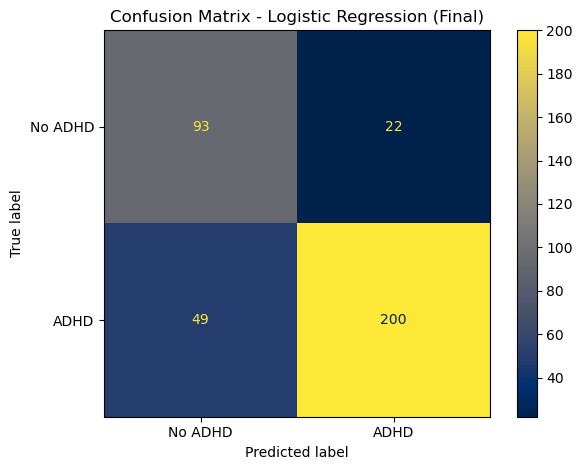

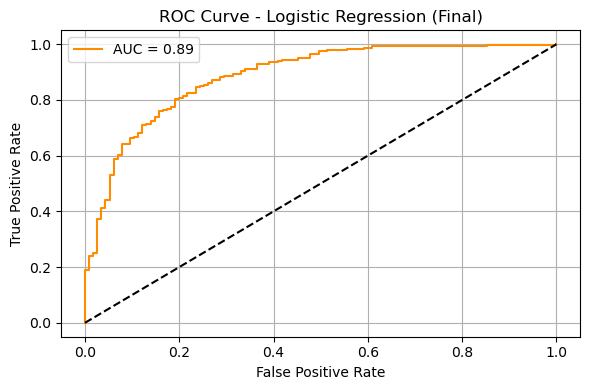

In [13]:
_ = analyze_model_performance(
    model=best_model_lg,
    model_name="Logistic Regression (Final)",
    features_train=features_train,
    labels_train=labels_train,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns,

    # Plot Styles
    confusion_cmap="cividis",       
    roc_curve_color="darkorange",  
    shap_color="yellow",         

    # Plots to show
    # I show important features of coefficients
    plot_feature_importance=False,  
    plot_roc_curve=True,            
    plot_confusion_matrix=True,
   
    # I skip SHAP plots
    plot_shap_bar=False,
    plot_shap_summary=False
)

# Analysis of output

In this part, I summarize the final evaluation of the Logistic Regression model once I had cross-validated and hyperparameter tuned (C=0.01) the unobserved test set.

**Model Performance:**
- Accuracy: 0.8049
- F1-score: 0.8493
- ROC AUC: 0.8853

These recorded results show how the model balances precision and recall on the held-out test set. The ROC AUC of approximately 0.89 summarizes ranking performance between the two recorded outcome classes.

**Confusion Matrix Interpretation:**
- The confusion matrix records 49 false negatives on this test set. The relative cost of false negatives and false positives would need to be defined for any intended use.

**ROC Curve Summary:**
- The ROC curve rises toward the upper-left region. An AUC of 0.89 indicates that the model ranks positive examples above negative examples in this held-out sample; it does not establish suitability for decision support. 

# 8.3 Interpreting Model with Logistic Regression Coefficients

I extract and visualize the **top 15 most influential features** learned by the last Logistic Regression model. I can visualize the magnitude of the coefficients of the model.

- A positive value indicates a feature that increases the chances of ADHD.
- Features represented by negative coefficients decrease the likelihood of ADHD.

**This analysis help me:**
- I see which features are driving the model's prediction.
- I check for unfairness if **Sex_F** is having too much of an influence.
- I increase trust by seeing why the model made its decision.

In [15]:
import pandas as pd
import numpy as np

def display_logreg_coefficients(model, feature_names, top_n=15):
    # Get coefficients
    coef = model.coef_[0]
    
    # I create dataframe
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    # Here is about show top N features
    print(f"\nTop {top_n} most influential features (by absolute value):")
    display(coef_df.head(top_n))

    return coef_df

coef_table = display_logreg_coefficients(best_model_lg, features_train.columns)


Top 15 most influential features (by absolute value):


,Feature,Coefficient
0,SDQ_SDQ_Hyperactivity,0.476208
1,SDQ_SDQ_Externalizing,0.328561
2,SDQ_SDQ_Difficulties_Total,0.221025
10,Basic_Demos_Enroll_Year,0.183317
4,SDQ_SDQ_Generating_Impact,0.170823
18,connectome_kpca_1,0.164646
38,Sex_F,-0.129377
11,MRI_Track_Scan_Location,0.128932
12,PreInt_Demos_Fam_Child_Race,-0.125392
34,connectome_kpca_17,-0.099600


# Analysis of output

The table shows the top 15 features that had the most influence on the final Logistic Regression model for predicting ADHD. 

**Key features that I can see:**
- The strongest predictors of ADHD include:
- **SDQ_SDQ_Hyperactivity** (coef: +0.47)
- **SDQ_SDQ_Externalizing** (coef: +0.32)
- **SDQ_SDQ_Difficulties_Total** (coef: +0.22)

The coefficients show that several SDQ questionnaire scores are prominent predictors in this fitted model.

- Also in the top list I can see demographic features like Basic_Demos_Enroll_Year and Sex_F.
- Scoring to predict ADHD likelihood, being female is associated with a decrease in likelihood. So, Sex_F has a negative coefficient (-0.13).
- This motivates further sex-based subgroup evaluation and, where appropriate, mitigation work.
- Components reflecting brain connections coming from Kernel PCA such as connectome_kpca_1, connectome_kpca_17, etc. are also impactful.

# 8.4 Fairness Evaluation by Gender

This piece of my code runs the analyze_fairness_by_sex function to check if the model is fair towards the male and female participants.

- The model uses Sex_F feature to divide the test set into female (Sex_F=1) and male (Sex_F=0).

**The evaluation is done separately for each group using:**
- **Accuracy**
- **F1-score**
- **ROC AUC**
- This analysis compares model performance across the two recorded sex groups and can identify gaps that warrant further investigation.

In [17]:
analyze_fairness_by_sex(
    model=best_model_lg,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns
)


=== Fairness Analysis by Sex ===

Group: Female (Sex_F=1)
  Accuracy: 0.7760
  F1-score: 0.7910
  ROC AUC: 0.8792

Group: Male (Sex_F=0)
  Accuracy: 0.8201
  F1-score: 0.8724
  ROC AUC: 0.8798


# Analysis of output

The analysis compares model performance between males and females based on gender. 

**Female Group Sex_F = 1**
- Accuracy: 0.7760
- F1-score: 0.7910
- ROC AUC: 0.8792

**Male Group Sex_F = 0**
- Accuracy: 0.8201
- F1-score: 0.8724
- ROC AUC: 0.8798

**My Key Observations are:**
1. outcome:
- The model does better on the males across all metrics.
- The difference between the two F1-scores of 0.8724 and 0.7910 is around 8% which is significant and indicates some examples of gender bias.

2. F1-Score Matters Most:
- F1-score is important as it’s a good measure of the precision recall of my model.
- If females have a low F1-score, it means either there are a lot of true positives missed (lower recall) or a lot of false positives (lower precision) being flagged for female participants.

3. The ROC AUC value almost is the same for males and females:
- The ROC AUC are both close (around 0.88) because this metric is threshold-independent, whereas F1-score is threshold-sensitive, the former is less useful in revealing real-world bias in classification.


# 9.1 Hyperparameter Tuning for Random Forest

I use the run_cv_and_tune() function to train a Random Forest Classifier using cross-validation and the randomized method to search for hyperparameters.

This function:
- By itself, manages **class imbalance** using **class_weight=’balanced’**.
- It does **RandomizedSearchCV** that finds the best combination of parameters.
- Provides the best model, the ideal ideal hyperparameters, and cross-validated F1-score.

In [19]:
best_model_rf, best_params_rf, best_score_rf = run_cv_and_tune(
    "Random Forest", features_train, labels_train
)


=== Best Parameters for Random Forest ===
{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
Mean F1 Score: 0.8548


# Analysis of output
- n_estimators = 100: It uses a moderate amount of trees that serve a good balance.
- min_samples_split = 2: The minimum number of samples needed to fracture a node, permitting very deep splits.
- max_depth = None: The trees allow to grow very deep (might lead to overfitting but can be mitigated by cross-validation).
- The mean of f1 score is 0.854. In this case, I can see a significant increase as compared to a logistic regression model (f1≈0.81). The above means that the Random Forest is able to capture more complex relations in the data.

# 9.2 Train and Evaluate Model: Random Forest 

I assess how well the Random Forest model performed on the test set and view its results:
- Confusion Matri shows classification accuracy between ADHD and non-ADHD.
- ROC Curve assesses how well the model separates between classes.
- Shap summary plot shows how predictions were made and which features are useful in prediction.


=== Random Forest (Final) ===
Accuracy: 0.8104
F1-score: 0.8681
ROC AUC: 0.8610


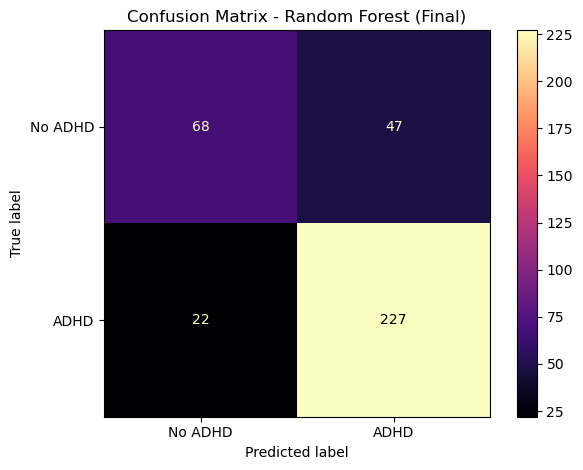

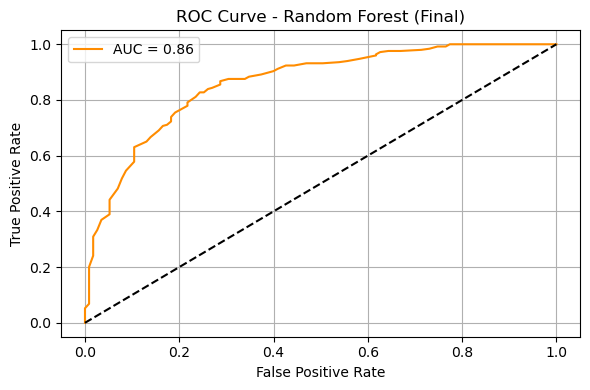

<Figure size 640x480 with 0 Axes>

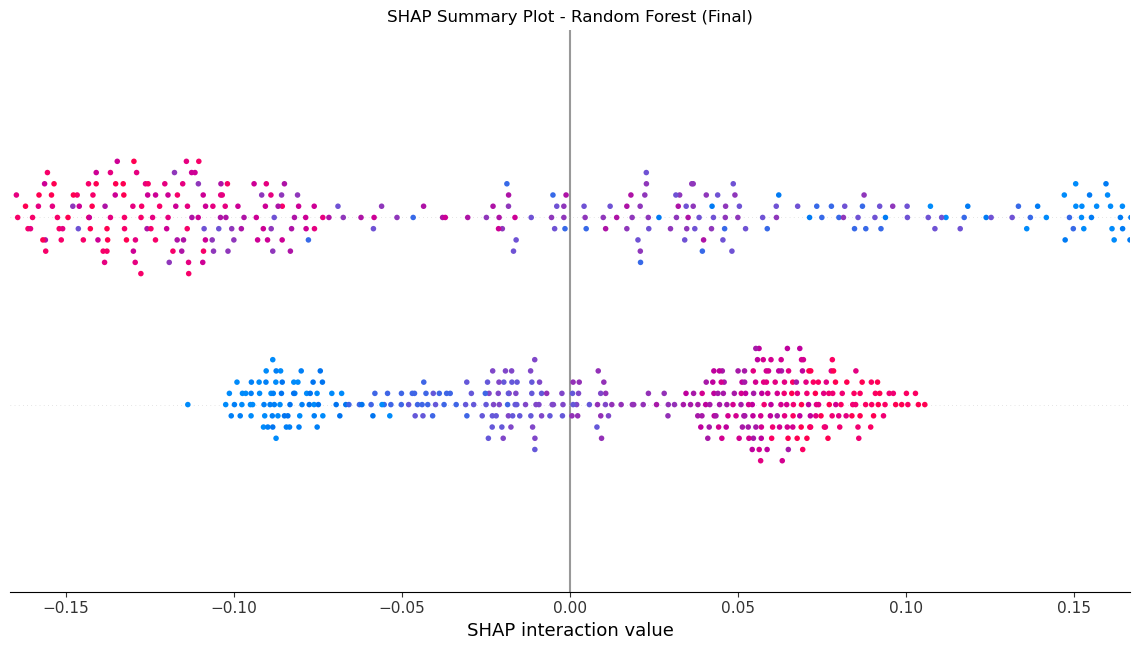

In [21]:
# Using the final Random Forest model
#best_model = best_model_rf 

# Performing final analysis with the Random Forest model
_=analyze_model_performance(
    model= best_model_rf,                        
    model_name="Random Forest (Final)",
    features_train=features_train,
    labels_train=labels_train,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns,

    # This part of my code is about setting colors
    confusion_cmap="magma",
    roc_curve_color="darkorange",
    shap_color="lightgreen",

    # This part of my code is about the charts that show in result
    plot_feature_importance=False,  
    plot_roc_curve=True,
    plot_confusion_matrix=True,
    plot_shap_bar=False,
    plot_shap_summary=True  
)

# Analysis of output

The Random Forest model performs well on the test data with classification.
- Accuracy: 0.8104
- F1-score: 0.8681
- ROC AUC: 0.8610

Confusion Matrix result that I see:
- 227 children are identify as they have ADHD correctly.  
- Only 22 children with ADHD were missed as no diagnosis, indicating strong sensitivity.
- 47 instances of having ADHD when it is not.
- 68 who were negative were predicted correctly as a true negative.

This records the balance between precision and recall on the held-out test set.

ROC Curve Analysis:
- The model's ROC AUC of 0.86 indicates that it is very good at distinguishing between the classes ADHD and nonADHD. Also, the true positive rates are robust across all thresholds.

SHAP Summary Plot:

The SHAP summary shows which features had the most impact.
- Most impactful are scores of SDQ Hyperactivity, Externalizing, and Difficulties.
- Features from fMRI images (like connectome_kpca_1) and inputs like Sex_F + Parent_Race also do things.

# 9.3 Fairness Evaluation by Gender

I can find if the Random Forest model is unfair with respect to gender by evaluating the performance on the test set for males (Sex_F=0) and for females (Sex_F=1). The following metrics were computed.
- Accuracy
- F1-score
- ROC AUC
  
The purpose of this exploratory analysis is to identify performance gaps between the two recorded sex groups.

Interpretation of Results:
- If the performance statistics (especially the F1-score) for females are significantly lower than those for males, this could indicate a bias in the model. 
- The difference in that case can be small, but if it is more than 5-10%, more reduction should is there.
- If the model steadily performs similarly for males and females, this suggests that the model is fair and I can trust it in application.

In [23]:
analyze_fairness_by_sex(
    model=best_model_rf,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns
)


=== Fairness Analysis by Sex ===

Group: Female (Sex_F=1)
  Accuracy: 0.7680
  F1-score: 0.8153
  ROC AUC: 0.8413

Group: Male (Sex_F=0)
  Accuracy: 0.8326
  F1-score: 0.8907
  ROC AUC: 0.8645


# Analysis of output
To assess whether there was a bias in my Random Forest model in terms of Sex_F, or more simply put, Gender, I calculated the accuracy, F1 score, and ROC AUC for females and males. 

Here is about my result that shows:
- Female (Sex_F=1)
- Accuracy: 0.7680
- F1-score: 0.8153
- ROC AUC: 0.8413
- Male (Sex_F=0)
- Accuracy: 0.8326
- F1-score: 0.8907
- ROC AUC: 0.8645

Explanation part:
- The gap in the F1-score is about 0.075 or 8.5% which is a significant difference.
- Accuracy is also higher for males. The model is more reliable on male participants.
- The ROC AUC indicates that the model can distinguish male participants than female participants since the score for males is higher but, overall both the scores are fairly strong as well. 

Conclusion:

I think models perform well overall, these differences show a small gender bias. This is especially crucial, as ADHD is frequently misdiagnosed in females, and a skewed model could amplify this problem.

# 10.1 Hyperparameter Tuning for XGBoost

In this part of my step, I want to use function and its name is **run_cv_and_tune()** for train an XGBoost classifier using randomized hyperparameter tuning.

Key advantages:
- I try to optimize for tabular data with an Efficient tree-based learning algorithm. 
- My plan is to manage missing values and imbalanced data well.
- Returns the best model with tuned hyperparameters and cross-validated F1-score

In [24]:
best_model_xgb, best_params_xgb, best_score_xgb = run_cv_and_tune(
    "XGBoost", features_train, labels_train
)



=== Best Parameters for XGBoost ===
{'scale_pos_weight': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Mean F1 Score: 0.8554


# Analysis of output

- The n_estimators equal 200 means the model is using 200 boosting rounds. That’s quite a decent size, not too small, which allows the model to learn well, but also not too large to risk overfitting.
- The max_depth equal  3 shows that each tree in the model is pretty shallow. This is actually a good sign, shallow trees are less likely to memorize the data and more likely to generalize, which is important for real-world performance.
- The learning rate equal 0.01 is quite low. This means the model is learning slowly, which is usually better when paired with more estimators. It helps avoid overshooting and makes the model more stable.
- The scale for class balancing (scale_pos_weight = 1) indicates that the model treated both classes equally. So, no extra emphasis was given to ADHD vs. non-ADHD, this suggests the class distribution is not too imbalanced, or I decided not to correct for it.
- The recorded mean cross-validation F1 score is 0.8554, summarizing the balance between precision and recall across the validation folds.

# 10.2 Train and Evaluate Model: XGBoost Model

I want to check how my final XGBoost model performs on the test data with the use of a few helpful visual tools:
1. Confusion Matrix: Shows me how many ADHD and non-ADHD cases the model predicts correctly or gets wrong. This data helps me understand if my model is missing values or giving false error.
2. Top Feature Importance: This tells me which features the model pays attention to the most. This gives me results into what kind of data is actually leading the predictions.
3. SHAP Summary Plot: This shows which features have the largest recorded contributions to the model output across the test set.



=== XGBoost (Final) ===
Accuracy: 0.8269
F1-score: 0.8777
ROC AUC: 0.8619


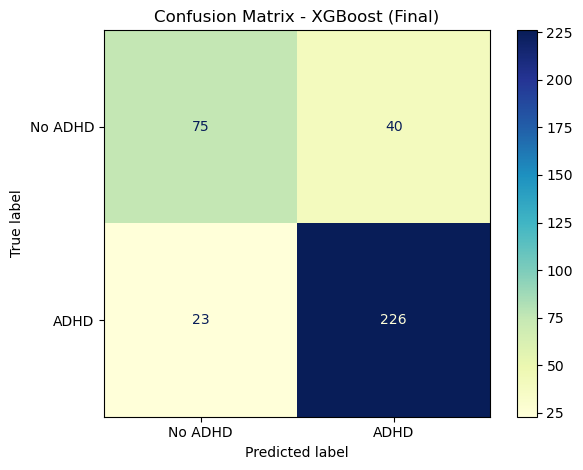

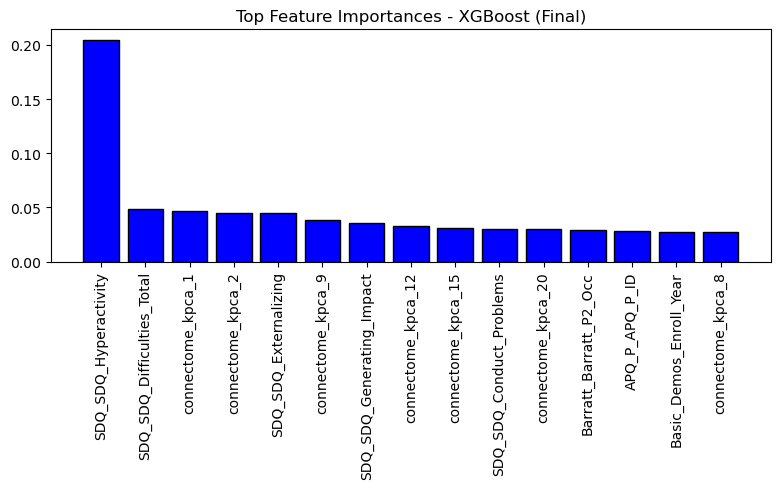

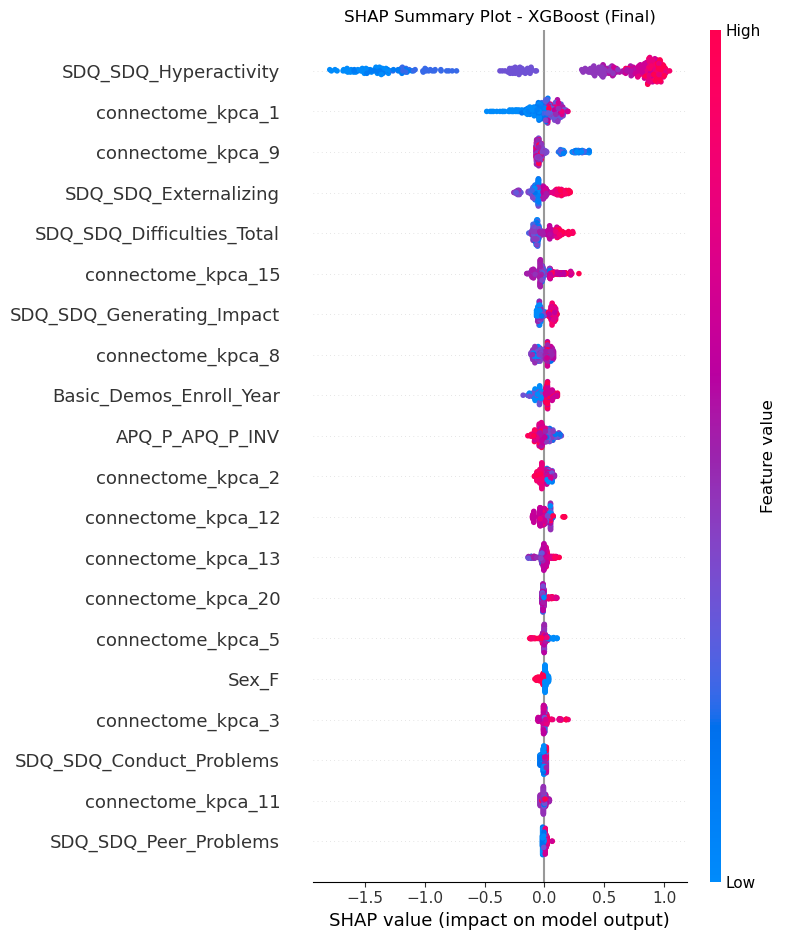

In [26]:
_=analyze_model_performance(
    model=best_model_xgb,
    model_name="XGBoost (Final)",
    features_train=features_train,
    labels_train=labels_train,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns,
    
    # Plot Options
    confusion_cmap="YlGnBu",
    roc_curve_color="darkorange",
    shap_color="blue",
    
    # Plots to show
    plot_feature_importance=True,
    plot_roc_curve=False,
    plot_confusion_matrix=True,
    plot_shap_bar=False,
    plot_shap_summary=True
)

# Analysis of output

Overall Model Performance:
- The result Accuracy equals 0.8269 showing 83% of predictions correct overall.
- The result of F1-score equal to 0.8777 gives me the model balances precision and recall really good.
- The result ROC AUC equal 0.8619 Shows model is good at telling the difference between ADHD and non-ADHD.

Confusion Matrix:
- 226 ADHD cases were predicted correctly. 
- 23 ADHD cases were missed and labeled as non-ADHD. 
- 75 non-ADHD cases predict correctly. 
- 40 non-ADHD cases were labelled wrongly as ADHD. 

This means my model is especially good at diagnosing ADHD cases, which is important for real-world.

Feature Importance Plot:
- Behavioral scores like hyperactivity have the most weight.
- Then are connectome features from fMRI data.

So basically, I can say that both brain imaging and behavior data worked well together to train a smart model 

SHAP Summary Plot:
- The SHAP plot shows me what features really affected the model’s predictions.
- Top one is SDQ_SDQ_Hyperactivity have influence in an ADHD study.
- Then I get some brain connectome components like connectome_kpca_1, kpca_9, and also SDQ Externalizing behaviors.

# 10.3  Fairness Evaluation by Gender

I want to check my XGBoost model works fairly for both boys and girls.

I want to do this because, in real life, girls with ADHD are sometimes not diagnosed properly. I want to make sure my model isn’t repeating that mistake.

I use a function called analyze_fairness_by_sex():
- Splits the test data into two groups one for males Sex_F = 0 and the other one for females Sex_F = 1.
- It runs the model separately on each group.
- My output includes Accuracy, F1-score, and ROC AUC.

I want to be sure my model:
- Works well for everyone.
- Doesn’t give better results just for one gender.
- These results are limited to the recorded held-out sample and do not establish external or real-world validity.


In [28]:
analyze_fairness_by_sex(
    model=best_model_xgb,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns
)


=== Fairness Analysis by Sex ===

Group: Female (Sex_F=1)
  Accuracy: 0.8240
  F1-score: 0.8590
  ROC AUC: 0.8712

Group: Male (Sex_F=0)
  Accuracy: 0.8285
  F1-score: 0.8858
  ROC AUC: 0.8492


# Analysis of output
I want to know my XGBoost model treats both females and males fairly. I wanted to make sure it doesn’t work better for one gender and worse for the other especially because ADHD is sometimes missed in girls.

My general results are:
- number 1 is about females detail: Accuracy: 0.8240, F1-score: 0.8590, and ROC AUC: 0.8712.
- number 0 is about males detail: Accuracy: 0.8285, F1-score: 0.8858, and ROC AUC: 0.8492.
  
This output means:
My model works almost the same for both groups. Males have a slightly higher F1-score, but females actually have a higher ROC AUC, which is a great sign. These small differences are totally acceptable and don’t show any serious bias.

# 11.1 Hyperparameter Tuning for LightGBM

I want to use this function to train and fine-tune my LightGBM model.
My goal here is to find the best settings (hyperparameters) so that the model can make better predictions. Instead of just picking random values, I let my code test different options automatically using cross-validation and choose the ones that give the best results.

This part of my code is important because:
- It improves the model’s performance.
- In this code, my result helps the model avoid overfitting.
- This makes the model more reliable for real-world data and people can use it.

Note: When you run my code is possible take a little time to load it please wait and see the result.

In [30]:
print ("Take a little Time, Please Wait, Thank you")
best_model_lgbm, best_params_lgbm, best_score_lgbm = run_cv_and_tune(
    "LightGBM", features_train, labels_train
)


Take a little Time, Please Wait, Thank you

=== Best Parameters for LightGBM ===
{'scale_pos_weight': 2, 'reg_lambda': 0.5, 'reg_alpha': 0.3, 'num_leaves': 120, 'n_estimators': 100, 'min_gain_to_split': 0.1, 'min_data_in_leaf': 30, 'learning_rate': 0.05}
Mean F1 Score: 0.8529


# Analysis of output:

- I assigned a higher weight to the ADHD class (which is in lower numbers) so as to avoid class imbalance.
- I set the regularization values to 0.5 and 0.3 respectively to limit overfitting.
- The variable num_leaves is set to 120 to determine how complex a decision tree can get. I’ve allowed a reasonably deep tree for flexibility.
- The model is using 100 boosting rounds (i.e. trees), which is a nice balance of speed and performance.
- The model avoids unnecessary complexity by only splitting when a meaningful gain occurs.
- The model has a restriction that each leaf contains a minimum of 30 samples, which helps in generalization.
- The learning rate is set to a low value (0.05) so that there’s a slower yet stable learning being implemented.

The mean F1 Score is 0.8529 which indicates that my model was pretty effective in balancing precision and recall in cross-validation. 


# 11.2 Train and Evaluate Model: LightGBM 

The final version of my LightGBM model is evaluated with this code. The analyze_model_performance function enables me to view and interpret the model performance.
- The confusion matrix displays the performance of the model as well as the true classes that it should have predicted. 
- The shap_bar is a straightforward bar graph for comparing features by their SHAP significance.
- shap_summary_plot is a simple plot that displays the contributions of each feature towards the prediction.


=== LightGBM (Final) ===
Accuracy: 0.7912
F1-score: 0.8555
ROC AUC: 0.8482


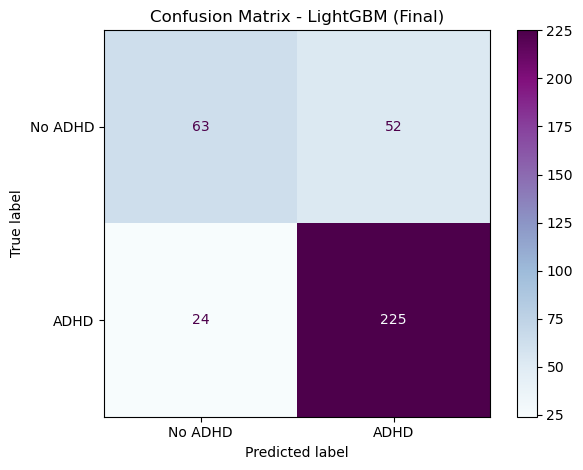

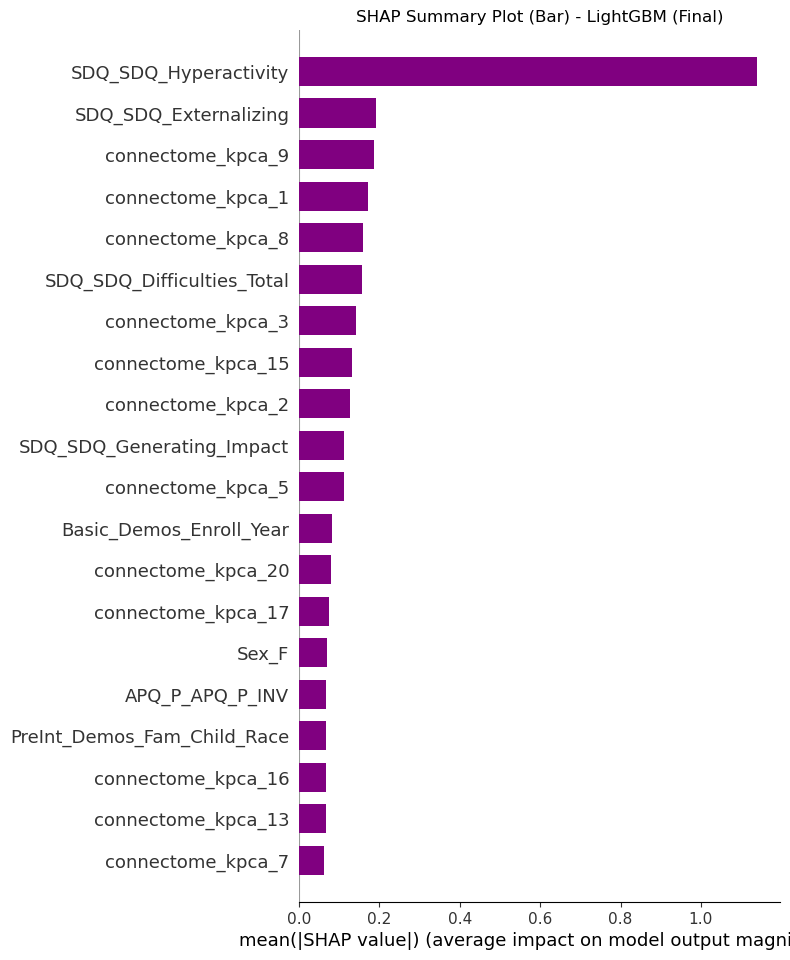

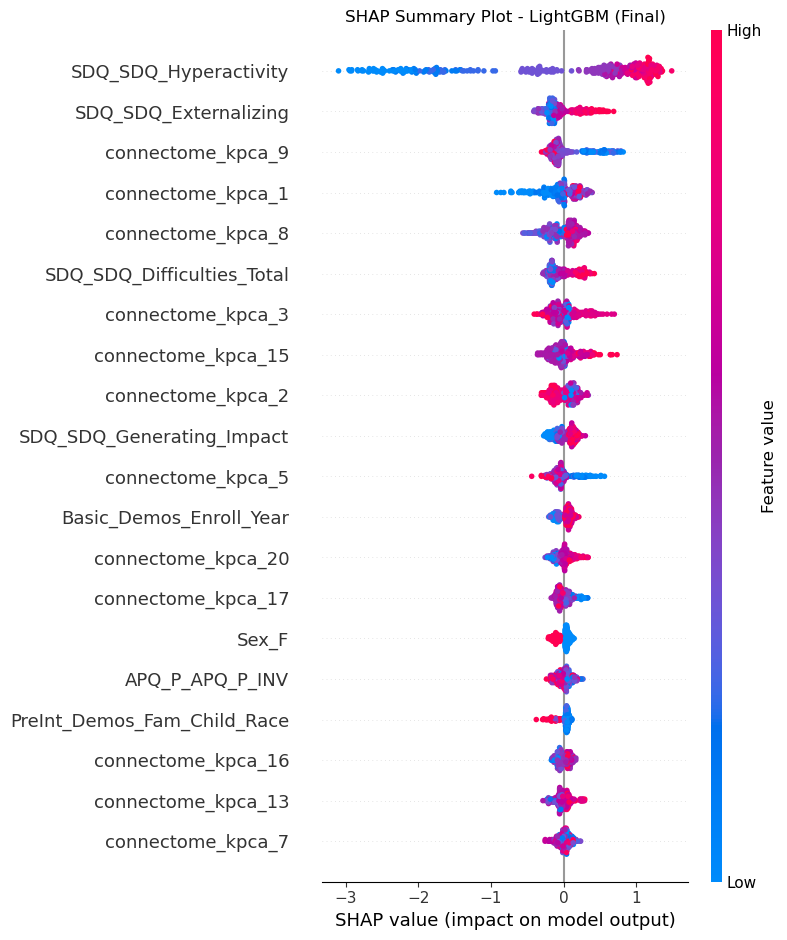

In [31]:
_=analyze_model_performance(
    model=best_model_lgbm,
    model_name="LightGBM (Final)",
    features_train=features_train,
    labels_train=labels_train,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns,
    confusion_cmap="BuPu",
    roc_curve_color="darkgreen",
    shap_color="purple",
    plot_feature_importance=False,
    plot_roc_curve=False,
    plot_confusion_matrix=True,
    plot_shap_bar=True,
    plot_shap_summary=True
)

# Analysis of output

Confusion Matrix give me these informations:
- The model has an accuracy of about 79%.
- The F1-score is about 85%, which is a better metric for imbalanced data.
- The Area Under The Curve (AUC) ROC is around 0.8482, showing the model is good at distinguishing between ADHD and non-ADHD.

- The model accurately identified 225 individuals with ADHD (True Positive).
- 63 people who do not have ADHD were also identified correctly (True Negative).
- 52 people who do not have ADHD were considered to have it.
- Only 24 missed ADHD cases (False Negative), shown that the recall is strong too. 

SHAP Summary Plot (Bar):
- The most influential factor was the SDQ_SDQ_Hyperactivity. Higher values increased the prediction of ADHD.
- The next most important feature is SDQ_SDQ_Externalizing, followed by several brain connectome features like connectome_kpca_9 and kpca_1.

SHAP Summary Plot:
- The biggest factor is the SDQ_SDQ_Hyperactivity score.
- Other important factors are SDQ scores, the KPCA components from the brain connectome, and even “Sex_F” (gender) made it there.

# 11.3  Fairness Evaluation by Gender

- I used analyze_fairness_by_sex to test if my final LightGBM model treated males and females fairly. Because girls often get diagnosed late (or rarely), I think it’s very important that the model is unbiased.
- The function is given the best model with the test features and labels which checks the performance of the model across sexes with parameters like Accuracy, F1-score, ROC AUC, etc.


In [35]:
analyze_fairness_by_sex(
    model=best_model_lgbm,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns
)


=== Fairness Analysis by Sex ===

Group: Female (Sex_F=1)
  Accuracy: 0.7360
  F1-score: 0.7925
  ROC AUC: 0.8355

Group: Male (Sex_F=0)
  Accuracy: 0.8201
  F1-score: 0.8828
  ROC AUC: 0.8462


# Analysis of output

The analyze_fairness_by_sex function helps in modeling performance analysis between two sexes generally known as males and females. 
- The female demographic had an accuracy of about 0.73. Further, the f1_score is 0.79 and ROC AUC is 0.83.
- My outcome for the male group shows accuracy equals to 0.82, f1-score around 0.88, and ROC AUC is 0.84.
- The model has shown a better performance for males comparing to females for all the metrics. There is quite a difference of F1-score, accuracy; it may be slightly predicting ADHD for male more accurately than female.

# 14. My Code for Collecting and Comparing Final Model Metrics

To complete the model evaluation step, I wrote this code to systematically collect the final performance metrics for all my trained models. To cleanly and visually compare Accuracy, F1 Score, and ROC AUC across the four algorithms (Logistic Regression, Random Forest, XGBoost, and LightGBM), I wrote this code.

I did in this code: 
- To begin with, I defined a dictionary called **models**, in which I stored my best final versions of each model. These were already tuned and trained previously.
- Next, I made a blank dictionary named **results** to save models computed metrics.
- For each model, I predicted the labels on the test set, and then calculated afterwards Accuracy, F1 Score, and ROC AUC.

I wrote this chart code:
- After computing the measurements, I did not want to just see the numbers in a table, I wanted to visually compare them side-by-side. To help me visualise differences in performance, I added this grouped bar chart.

To make it easier to read, I even added:
- Bars for every metric have colours.
- Labels above every bar show the score.
- Adjusted layout and formatting on axes.

This was really helpful in helping me determine which model performs best overall, and gave me a nice visual for my report.

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression (Final),0.8049,0.8493,0.8853
1,Random Forest (Final),0.8104,0.8681,0.8610
2,XGBoost (Final),0.8269,0.8777,0.8619
3,LightGBM (Final),0.7912,0.8555,0.8482


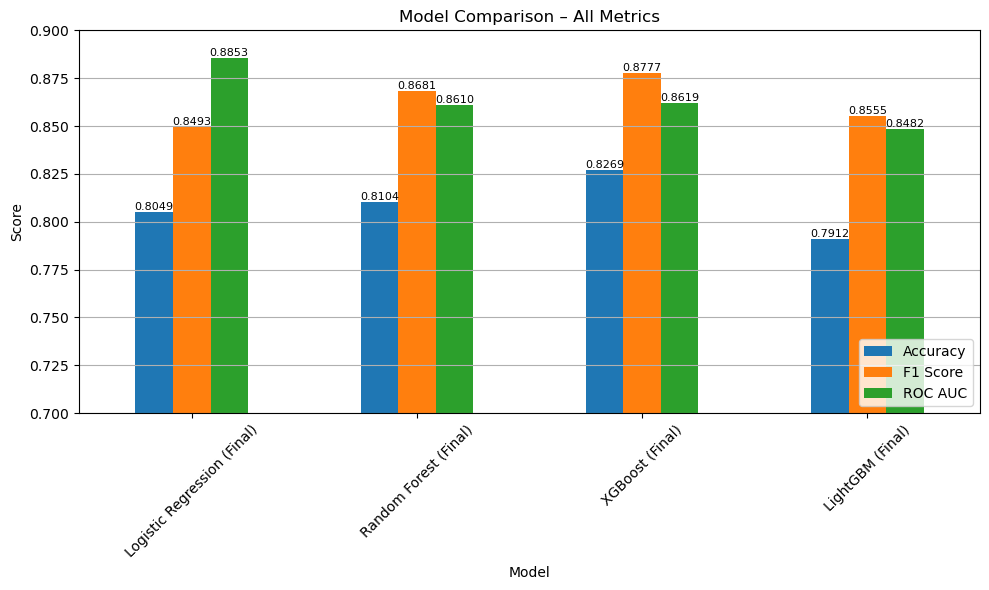

In [37]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# I define model dictionary with model names and final trained models
models = {
    "Logistic Regression (Final)": best_model_lg,          
    "Random Forest (Final)": best_model_rf,
    "XGBoost (Final)": best_model_xgb,
    "LightGBM (Final)": best_model_lgbm
}

# Initialize results dictionary
results = {
    "Model": [],
    "Accuracy": [],
    "F1 Score": [],
    "ROC AUC": []
}

# I create a loop through each model and compute metrics on test set
for model_name, model in models.items():
    y_pred = model.predict(features_test)
    y_proba = model.predict_proba(features_test)[:, 1]

    results["Model"].append(model_name)
    results["Accuracy"].append(round(accuracy_score(labels_test, y_pred), 4))
    results["F1 Score"].append(round(f1_score(labels_test, y_pred), 4))
    results["ROC AUC"].append(round(roc_auc_score(labels_test, y_proba), 4))

# Here I create DataFrame for easy comparison
comparison_df = pd.DataFrame(results)
display(comparison_df)

# Draw the chart
ax = comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison – All Metrics")
plt.ylabel("Score")
plt.ylim(0.7, 0.9)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.tight_layout()

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=8)

plt.show()

# Final Model Comparison

Once I have trained and tuned all four models, I want to compare the final performance of the models more clearly based on the three metrics Accuracy, F1 Score, and ROC AUC. These metrics help me analyze not only how many predictions were correct but also how each model balanced false positives and false negatives, which is very important for ADHD detection.

**Logistic Regression (Final):**
- Logistic Regression recorded an Accuracy of 0.8049, an F1 Score of 0.8493, and a ROC AUC of 0.8853. Although it was not the most accurate model, it recorded the highest ROC AUC and offers directly inspectable coefficients.

**Random Forest (Final):**
- This model achieved a good balance of performance as I observed that the Random Forest had an Accuracy of 0.8104, F1 Score of 0.8681, and ROC AUC of 0.8610. I think it is a strong condidate when I require reliable results while also benefitting from some interpretability through feature importance. It showed better overall accuracy compared to Logistic Regression, but not as good ROC AUC.

**XGBoost (Final):**
- XGBoost clearly stood out in my testing. I noticed an F1 Score peak of 0.8777 and a high Accuracy of 0.8269, with a ROC AUC of 0.8619. If I want the best performance, I’d choose this model. I trust it the most for the main classification task of this project because it handles imbalance very well and generalizes very well.

**LightGBM (Final):**
- Although LightGBM is fast and light weight, I got quite low scores for this model. Accuracy = 0.7912, F1 Score = 0.8555, ROC AUC = 0.8482 It's not an unsatisfactory model but I noticed that it did not perform as well as the others. I may still use it for real-time situations but for this project I need something with a little more accuracy and robustness.

**My Final Thoughts:**
- After looking at everything closely, I would personally pick **XGBoost** as the best model. I’m comfortable with its balance between precision and recall (F1), it accuracy, and its ROC AUC.
- Logistic Regression provides a simpler coefficient-based explanation, while this alone does not establish regulatory compliance.

# 15. Gender Bias Analysis Across All Final Models

- For each of my final models, I will check if it has any gender bias. This is done by checking the performance of the model separately for males and females. I made a loop that runs through each of the models fitted on the test data, filtering by gender that is Sex_F. I determine the accuracy, F1-score, and ROC AUC for each group (Female and Male).
- After gathering all the metrics for each model and for both genders, I put it all in a clean data frame. Next, I defined the order of the model’s appearance in the plot. This is so that the topic will be easy to follow and read as well.
- For all three metrics, the grouped bar chart compares recorded performance across the two sex groups. Observed gaps are exploratory and do not constitute a fairness certification or a statistical-significance test.
- I included value labels on top of each bar to make the plot easy to read and useful. I am now better positioned to actually go ahead and rectify my imaging bias; I will be fairer for the right reasons.



-- Analyzing Bias for Logistic Regression (Final) --


-- Analyzing Bias for Random Forest (Final) --


-- Analyzing Bias for XGBoost (Final) --


-- Analyzing Bias for LightGBM (Final) --


,Model,Group,Accuracy,F1 Score,ROC AUC
0,Logistic Regression (Final),Female (Sex_F=1),0.7760,0.7910,0.8792
1,Logistic Regression (Final),Male (Sex_F=0),0.8201,0.8724,0.8798
2,Random Forest (Final),Female (Sex_F=1),0.7680,0.8153,0.8413
3,Random Forest (Final),Male (Sex_F=0),0.8326,0.8907,0.8645
4,XGBoost (Final),Female (Sex_F=1),0.8240,0.8590,0.8712
5,XGBoost (Final),Male (Sex_F=0),0.8285,0.8858,0.8492
6,LightGBM (Final),Female (Sex_F=1),0.7360,0.7925,0.8355
7,LightGBM (Final),Male (Sex_F=0),0.8201,0.8828,0.8462


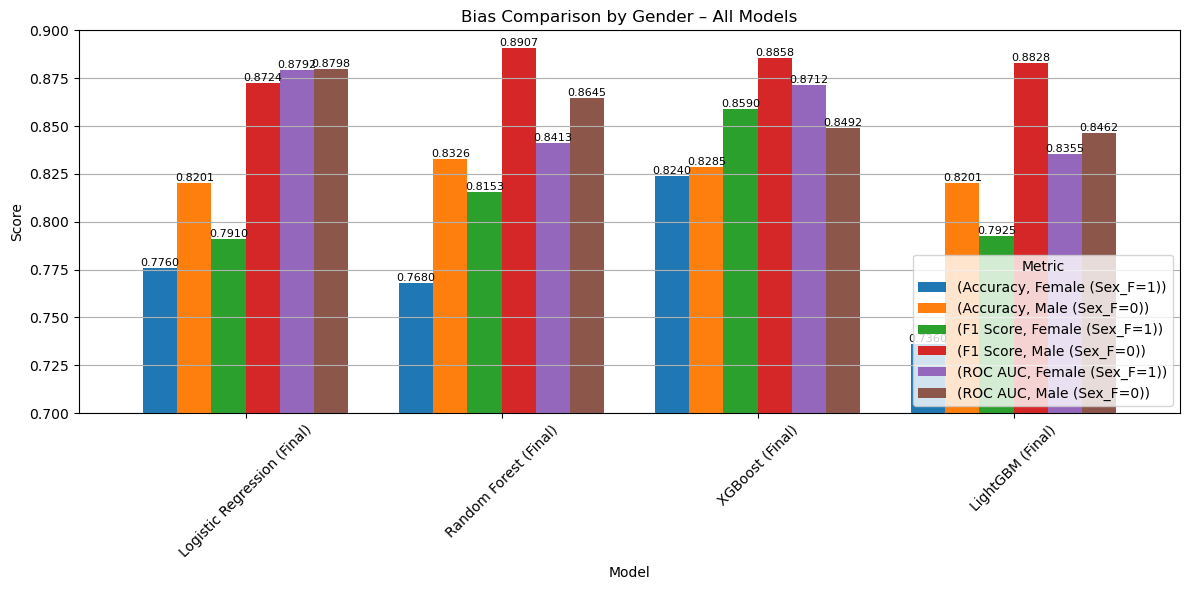

In [39]:
# I save the results of the Bias comparison
bias_results = {
    "Model": [],
    "Group": [],
    "Accuracy": [],
    "F1 Score": [],
    "ROC AUC": []
}

# List of my models
models = {
    "Logistic Regression (Final)": best_model_lg,
    "Random Forest (Final)": best_model_rf,
    "XGBoost (Final)": best_model_xgb,
    "LightGBM (Final)": best_model_lgbm
}

# I do the function for each model
for model_name, model in models.items():
    print(f"\n\n-- Analyzing Bias for {model_name} --")
    
    sex_f_index = list(features_train.columns).index('Sex_F')
    is_female = features_test.iloc[:, sex_f_index] == 1
    is_male = features_test.iloc[:, sex_f_index] == 0

    groups = {
        "Female (Sex_F=1)": is_female,
        "Male (Sex_F=0)": is_male
    }

    for group_name, mask in groups.items():
        X_group = features_test[mask]
        y_true = labels_test[mask]
        y_pred = model.predict(X_group)
        y_proba = model.predict_proba(X_group)[:, 1]

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_proba)

        bias_results["Model"].append(model_name)
        bias_results["Group"].append(group_name)
        bias_results["Accuracy"].append(round(acc, 4))
        bias_results["F1 Score"].append(round(f1, 4))
        bias_results["ROC AUC"].append(round(roc_auc, 4))

# Convert to final table
bias_comparison_df = pd.DataFrame(bias_results)
display(bias_comparison_df)

import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

# Define the desired order of models
model_order = [
    "Logistic Regression (Final)",
    "Random Forest (Final)",
    "XGBoost (Final)",
    "LightGBM (Final)"
]

# I set the categorical order for the 'Model' column
bias_comparison_df["Model"] = bias_comparison_df["Model"].astype(
    CategoricalDtype(categories=model_order, ordered=True)
)

# Draw Bias Comparison Chart
fig, ax = plt.subplots(figsize=(12, 6))
bias_comparison_df.set_index(["Model", "Group"]).unstack().plot(
    kind="bar", ax=ax, width=0.8
)

plt.title("Bias Comparison by Gender – All Models")
plt.ylabel("Score")
plt.ylim(0.7, 0.9)
plt.xticks(rotation=45)
plt.legend(title="Metric", loc="lower right")
plt.grid(axis="y")
plt.tight_layout()

# I add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=8)

plt.show()

# Gender Bias Analysis

- After looking at the performance of all four final models separately for males and females, I learned some interesting things about gender fairness.
- To begin with, I calculated Accuracy, F1 Score, and ROC AUC for both groups across all models. As I checked the results, I observed that there is a consistent performance gap between males and females, especially in F1 Score and Accuracy.
- For instance, I noticed that the LightGBM model showed a significant difference in performance: its Accuracy for females was 0.7360 while for males it was 0.8201. The F1 Score and ROC AUC followed a similar pattern. It made me worried about fairness because it indicates that the performance of the model is not as good for females.
- I observed that XGBoost shows the most balanced performance for male and female participants. The differences in all three metrics are small enough as compared to the other model which makes me feel confident about its fairness.
- The Random Forest model had strong performance overall but did show a tendency for males to receive higher scores the F1 Score is a huge example of this (0.8907 for males vs 0.8153 for females).
- I think using a grouped bar chart to visualize the data helped me understand the imbalance quickly. The bar chart shows the higher scores for males across almost all models, and I feel that really helped me in deciding which model is more fair.
- To sum it all up, I suspect that even though each model showed some sort of gender bias, **XGBoost is the fairest model** among all.

# 16. Final Model Selection and Explanation with SHAP

- After examining all 4 models, I select **XGBoost (Final)** as my final model. I choose it because it had the best overall performance in Accuracy and F1 Score and also it showed the **least amount of gender bias** in my fairness analysis. 
- SHAP is used to inspect global feature contributions for the selected model.

I create two SHAP plots:
1. SHAP summary plot (Bar) highlights the most important features of all predictions.
2. The next plot is a SHAP Summary Plot Its purpose is to see how the feature (Sex_F) affects the output of the model.  It helps me to see if gender plays a part.


=== XGBoost (Final) ===
Accuracy: 0.8269
F1-score: 0.8777
ROC AUC: 0.8619


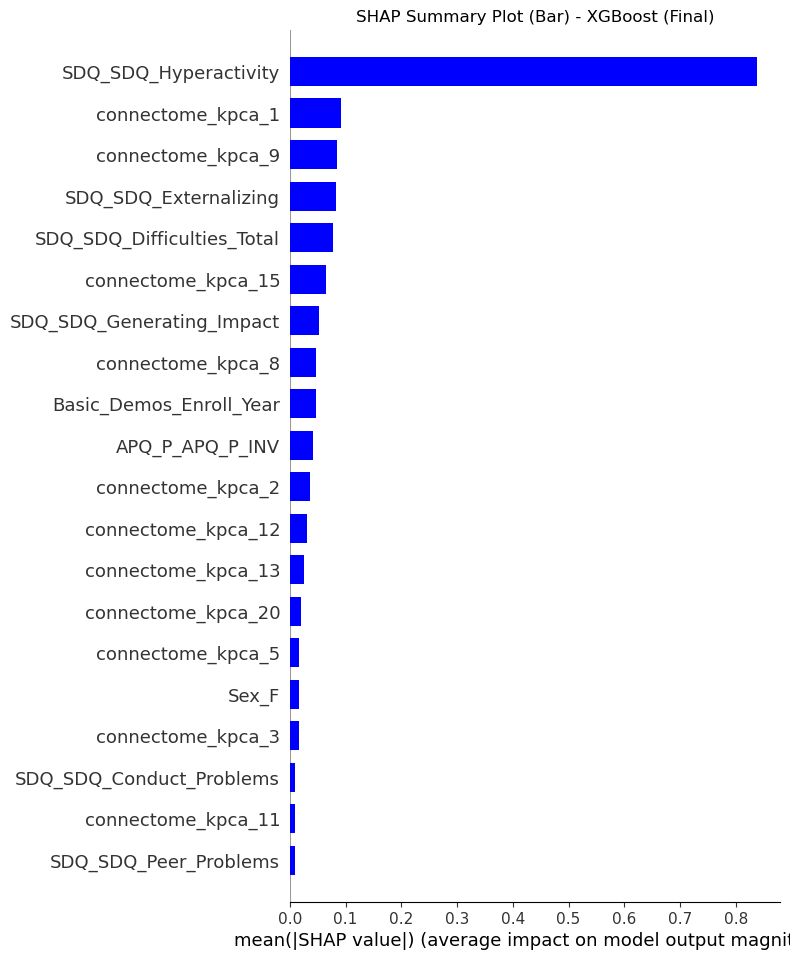

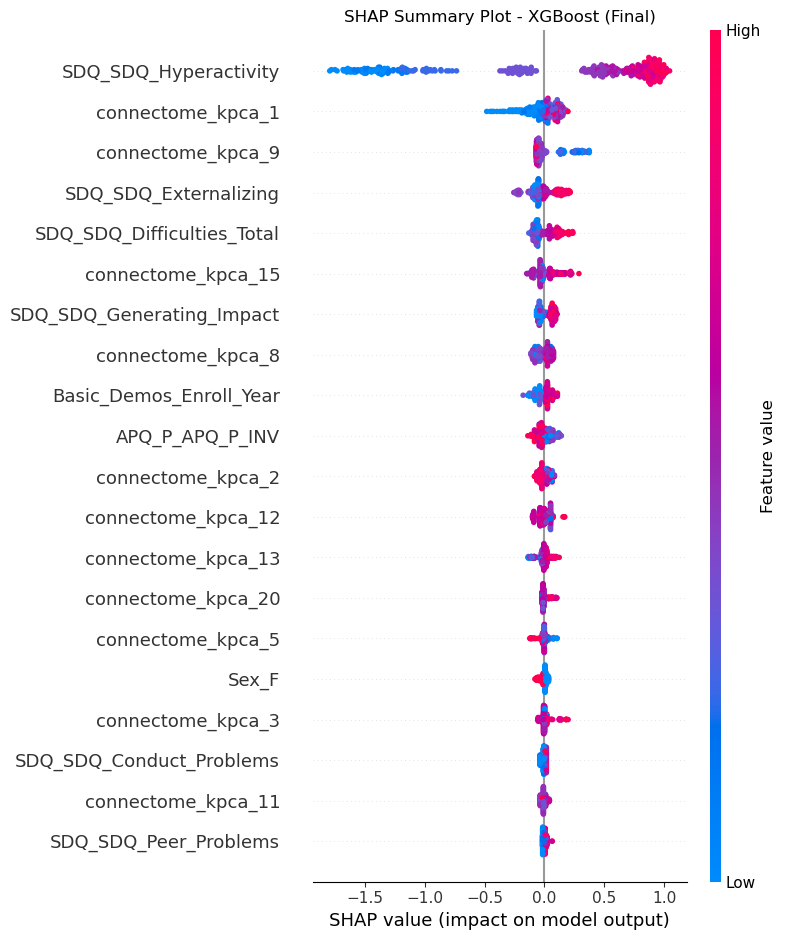

In [41]:
_=analyze_model_performance(
    model=best_model_xgb,
    model_name="XGBoost (Final)",
    features_train=features_train,
    labels_train=labels_train,
    features_test=features_test,
    labels_test=labels_test,
    feature_names=features_train.columns,

    # Plot Options
    confusion_cmap="YlGnBu",
    roc_curve_color="darkorange",
    shap_color="blue",

    # Plots to show
    plot_feature_importance=False,
    plot_roc_curve=False,
    plot_confusion_matrix=False,
    plot_shap_bar=True,
    plot_shap_summary=True
)

# SHAP Analysis and Why I Choose XGBoost as the Final Model

To explain the selection of XGBoost (Final), I used SHAP to evaluate global feature importance and the distribution of feature contributions across test examples. These explanations describe the fitted model rather than causal or medical effects.

1. SHAP Summary Plot (Bar):
- The first SHAP plot was a bar chart of mean absolute SHAP values for features. This gives me a clear picture of which features had the greatest overall impact on the predictions.
- I found that the SDQ_SDQ_Hyperactivity was hands down the most important.
- The model also made quite a few predictions based on several connectome features, such as connectome_kpca_1, kpca_9, kpca_15, etc. This shows that brain imaging data also contributes meaningfully to model decisions.
- The Sex_F feature has a low mean SHAP value, indicating that my model does not rely on gender in general. I believe this is a good sign in terms of fairness.
- This plot suggests that color-based similarity in the distributions will help my model learn from medically and neurologically relevant data and not merely from demographic-based bias.

2. SHAP Summary Plot:
- The second plot helps me understand better how the individual value of features impacts the direction of prediction of ADHD or not. This shows the distribution of SHAP values per feature (one per color) and their value (blue = low, pink = high).
- From this chart, I noticed that high values of SDQ_SDQ_Hyperactivity (in pink) consistently drive the prediction toward ADHD, which makes perfect sense.
- I noticed connectome components like connectome_kpca_1 will also pull the prediction to ADHD but subtly.
- I noticed that sex is also not an important feature affecting prediction outcome. It makes sense since this should not be a reason for a prediction related to ADHD. This is precisely what I was seeking a model that is both effective and gender-neutral.

Final Thoughts:
- SHAP complements the recorded XGBoost test F1 score of 0.8777 with model-level explanations. It does not establish regulatory compliance, clinical trustworthiness, or fairness.